In [23]:
!pip3 install -U ucimlrepo

In [24]:
#IMPORTS
# Manipulação de dados e visualização
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Modelos, métricas e ferramentas do Scikit-Learn
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Repositório de datasets da UCI
from ucimlrepo import fetch_ucirepo, list_available_datasets

In [25]:
# import dataset
heart_disease = fetch_ucirepo(id=45)
# access data
X = heart_disease.data.features
y = heart_disease.data.targets
# train model e.g. sklearn.linear_model.LinearRegression().fit(X, y)
# access metadata
print(heart_disease.metadata.uci_id)
print(heart_disease.metadata.num_instances)
print(heart_disease.metadata.additional_info.summary)
# access variable info in tabular format
print(heart_disease.variables)
print(X)
print(y)

45
303
This database contains 76 attributes, but all published experiments refer to using a subset of 14 of them.  In particular, the Cleveland database is the only one that has been used by ML researchers to date.  The "goal" field refers to the presence of heart disease in the patient.  It is integer valued from 0 (no presence) to 4. Experiments with the Cleveland database have concentrated on simply attempting to distinguish presence (values 1,2,3,4) from absence (value 0).  
   
The names and social security numbers of the patients were recently removed from the database, replaced with dummy values.

One file has been "processed", that one containing the Cleveland database.  All four unprocessed files also exist in this directory.

To see Test Costs (donated by Peter Turney), please see the folder "Costs" 
        name     role         type demographic  \
0        age  Feature      Integer         Age   
1        sex  Feature  Categorical         Sex   
2         cp  Feature  Categ

In [26]:
#numero de pacientes, ou seja amostras
print("Número de linhas (pacientes): ", X.shape[0])
#numero de atributos, ou seja oq pode identificado de cada paciente
print("Número de colunas (atributos):", X.shape[1])
#qual o tipo de cada atributo dos pacientes, nesses caso a maioria são inteiros (int64) e alguns floats (float64)
print()
print(X.dtypes)
#qual a quantidade de atributos nulos em todo o database, nesse caso há somente 4 em ca e 2 em thal. Isso é importante pois o algorítimo pode travar ao ver um valor nulo.
print()
print(X.isnull().sum())
#qual o tipo do atributo num, que é o atributo resposável pelo resultado final, se há doença cardíaca ou não.
print()
print(y.dtypes)
#quantos pacientes há em cada tipo de num, que varia de 0 a 4 (que é a variação de grau: 0, sem doença; 1, doença grau 1; 2, doença grau 2; 3, doença grau 3; 4, doença grau 4).
print()
print(y['num'].value_counts().sort_index())

Número de linhas (pacientes):  303
Número de colunas (atributos): 13

age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca          float64
thal        float64
dtype: object

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
dtype: int64

num    int64
dtype: object

num
0    164
1     55
2     36
3     35
4     13
Name: count, dtype: int64


In [27]:
#Porém para a simplificação do projeto vamos entender que 0 sera classificado como sem doença e 1 com doença, sendo o 0 = (0) e o 1 = (1, 2, 3, 4). Podendo assim definir o caso como de classificação.
#Ou seja, ficaria assim:
y_binario = (y['num'] > 0).astype(int)
print(y_binario.value_counts().sort_index())
#Sendo perceptível que temos 164 pessoas classificadas como sem doença cardíaca, e 139 classificadas como com doença cardíaca.

num
0    164
1    139
Name: count, dtype: int64


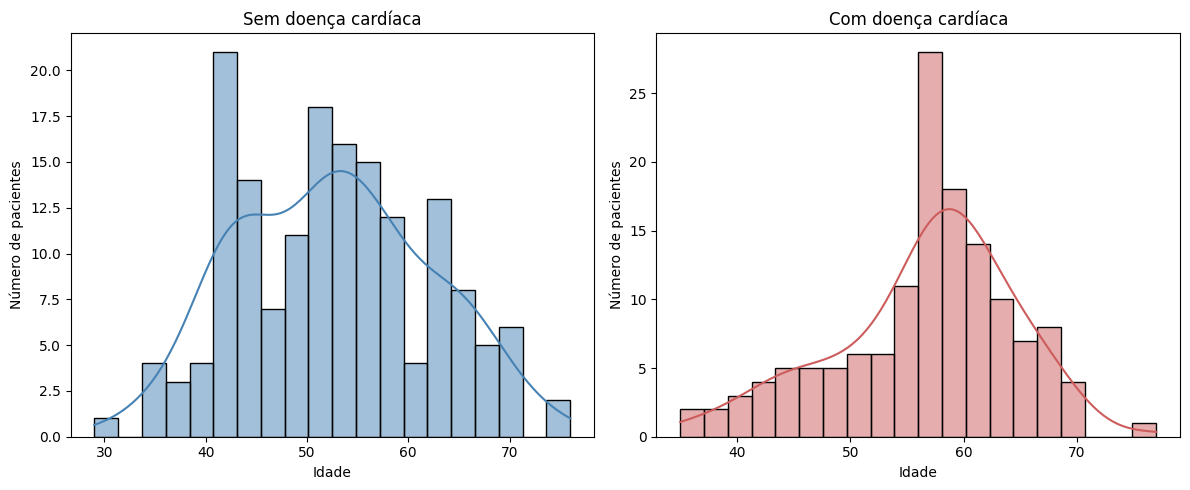

In [28]:
#EDA
#CÓDIGO DO GRÁFICO GERADO POR IA (Claude Sonnet 5)

dados_grafico = X.copy()
dados_grafico['tem_doenca'] = y_binario

fig, eixos = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(data=dados_grafico[dados_grafico['tem_doenca'] == 0], x='age', kde=True, bins=20, ax=eixos[0], color='steelblue')
eixos[0].set_title('Sem doença cardíaca')
eixos[0].set_xlabel('Idade')
eixos[0].set_ylabel('Número de pacientes')

sns.histplot(data=dados_grafico[dados_grafico['tem_doenca'] == 1], x='age', kde=True, bins=20, ax=eixos[1], color='indianred')
eixos[1].set_title('Com doença cardíaca')
eixos[1].set_xlabel('Idade')
eixos[1].set_ylabel('Número de pacientes')

plt.tight_layout()
plt.show()
#Com a análise de gráficos por idade é possível perceber se há alguma relação da idade com o número de pacientes com ou sem doença cardíaca, nesse caso há sim, é possivel afirmar pois os gráfico
#com doença mostra um pico de pessoas principalmente na faixa de 60 anos, coisa que não acontece no gráfico sem doença, que tem vários picos. Demonstrando que a idade impacta na chance de uma doença cardíaca.

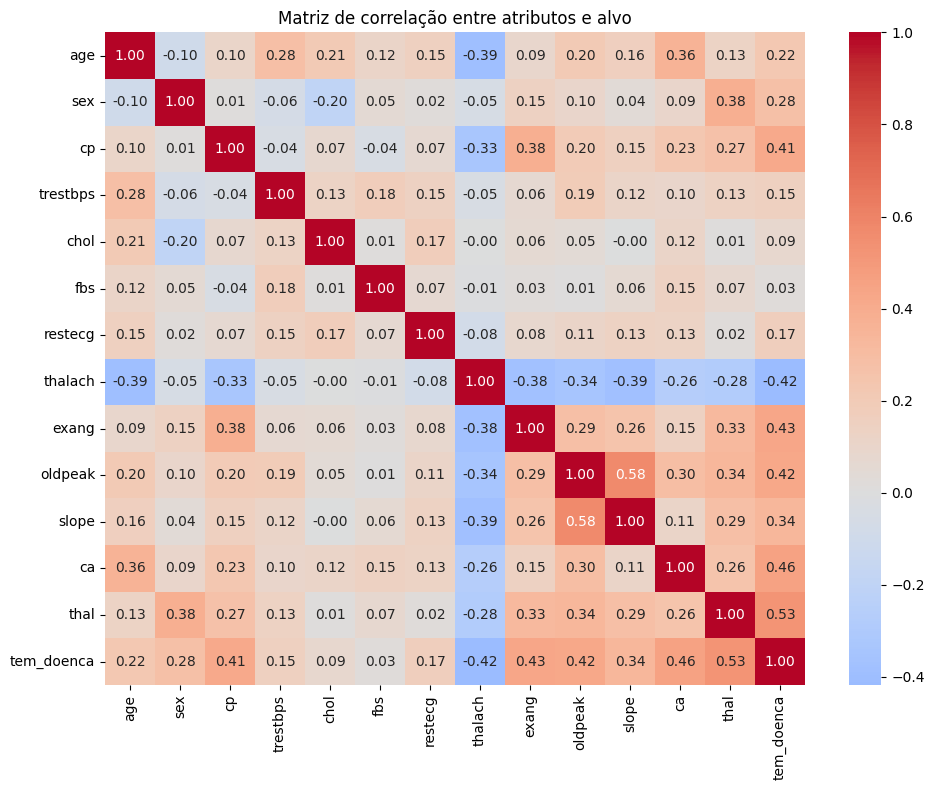

In [29]:
#Para simplificar as coisas, essa é uma matriz de correlação, ela ajuda na melhor compreensão dos dados, mostrando a "importância" dos dados em relação a tem doença.
#Por exemplo, entre sexo e tem doença existe uma correlação de 0.28, isso serio o grau de "importancia" desse atributo ao resultado, se tem doença ou não.
#CÓDIGO DA MATRIZ GERADO POR IA (Claude Sonnet 5)


dados_corr = X.copy()
dados_corr['tem_doenca'] = y_binario

matriz_correlacao = dados_corr.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(matriz_correlacao, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Matriz de correlação entre atributos e alvo')
plt.tight_layout()
plt.show()

In [30]:
#Indo para a parte de pre-processamento, vamos cuidar dos dados nulos, que podem travar o algorítimo.
dados_completos = X.copy()
dados_completos['tem_doenca'] = y_binario
dados_completos = dados_completos.dropna()
print(dados_completos.isnull().sum())
print("Total de pacientes restantes:", dados_completos.shape[0])

age           0
sex           0
cp            0
trestbps      0
chol          0
fbs           0
restecg       0
thalach       0
exang         0
oldpeak       0
slope         0
ca            0
thal          0
tem_doenca    0
dtype: int64
Total de pacientes restantes: 297


In [31]:
#Alguns atributos como o 'cp' são classificados com varios numeros, nesse caso por exemplo, de 1 a 4, porem
#esses numeros não apresentam nenhuma diferença de magnitude (a cp nível 1, não é mais importante que a
#nível 2 ou 3, e sim apenas apresenta uma 'dor' diferente)
#Se essas colunas forem usadas diretamente pelos modelos, alguns algoritmos podem
#interpretar erroneamente que existe uma relação numérica entre as categorias (por
#exemplo, que a distância entre os tipos 1 e 4 é maior que entre os tipos 1 e 2).
#Para evitar esse problema, aplicaremos a técnica de one-hot encoding, que transforma
#cada coluna categórica em múltiplas colunas binárias (0 ou 1), uma para cada categoria
#possível, eliminando qualquer noção de ordem entre os valores.
#E depois de uma análise dos atributos foi possível perceber que as colunas cp, restecg, slope, ca e thal precisam da aplicação do one-hot encoding.

In [32]:
#Para o código do Hot-Encoding temos:

colunas_categoricas = ['cp', 'restecg', 'slope', 'ca', 'thal']

dados_final = pd.get_dummies(dados_completos, columns=colunas_categoricas)

print("Colunas antes:", dados_completos.shape[1])
print("Colunas depois:", dados_final.shape[1])
print(dados_final.columns.tolist())
#Ou seja agora os atributos citados anteriormente tem níveis diferentes definidos por valores binários (0 e 1).
print(dados_final)

Colunas antes: 14
Colunas depois: 26
['age', 'sex', 'trestbps', 'chol', 'fbs', 'thalach', 'exang', 'oldpeak', 'tem_doenca', 'cp_1', 'cp_2', 'cp_3', 'cp_4', 'restecg_0', 'restecg_1', 'restecg_2', 'slope_1', 'slope_2', 'slope_3', 'ca_0.0', 'ca_1.0', 'ca_2.0', 'ca_3.0', 'thal_3.0', 'thal_6.0', 'thal_7.0']
     age  sex  trestbps  chol  fbs  thalach  exang  oldpeak  tem_doenca  \
0     63    1       145   233    1      150      0      2.3           0   
1     67    1       160   286    0      108      1      1.5           1   
2     67    1       120   229    0      129      1      2.6           1   
3     37    1       130   250    0      187      0      3.5           0   
4     41    0       130   204    0      172      0      1.4           0   
..   ...  ...       ...   ...  ...      ...    ...      ...         ...   
297   57    0       140   241    0      123      1      0.2           1   
298   45    1       110   264    0      132      0      1.2           1   
299   68    1       1

In [33]:
#Agora vamos para a seleção de dados treino e teste, pois se fizermos uma análise dos dados primeiro e depois separarmos eles em treino e teste, haverá um vazamento de dados, que
#podera influenciar no resultado do algorítimo.


X_dados = dados_final.drop(columns=['tem_doenca'])
y_dados = dados_final['tem_doenca']

X_treino, X_teste, y_treino, y_teste = train_test_split(
    X_dados, y_dados, test_size=0.2, random_state=42, stratify=y_dados
)

print("Tamanho treino:", X_treino.shape)
print("Tamanho teste:", X_teste.shape)
#Os dados foram divididos em 80% para treino e 20% para teste, utilizando estratificação para manter a proporção de pacientes com
#e sem doença cardíaca equilibrada em ambos os conjuntos. Foi definida uma semente
#fixa (`random_state=42`) isso faz com que todas as vezes rodadas tenham os mesmos dados.

Tamanho treino: (237, 25)
Tamanho teste: (60, 25)


In [34]:
#As colunas numéricas contínuas (`age`, `trestbps`, `chol`, `thalach`, `oldpeak`)
#possuem escalas muito diferentes entre si (por exemplo, `chol` varia em centenas
#enquanto `oldpeak` varia entre 0 e 6). Isso pode fazer com que algoritmos sensíveis
#a distância deem peso desproporcional às variáveis de maior escala.
#Para corrigir isso, aplicamos a padronização (`StandardScaler`), que transforma cada
#valor com base na distância em relação à média, medida em desvios padrão. As
#estatísticas (média e desvio padrão) foram calculadas apenas com os dados de treino,
#e aplicadas em seguida também ao teste, evitando vazamento de informação entre os
#conjuntos.


colunas_numericas = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

scaler = StandardScaler()

X_treino_escalonado = X_treino.copy()
X_teste_escalonado = X_teste.copy()

X_treino_escalonado[colunas_numericas] = scaler.fit_transform(X_treino[colunas_numericas])
X_teste_escalonado[colunas_numericas] = scaler.transform(X_teste[colunas_numericas])

pd.set_option('display.max_columns', None)
X_treino_escalonado.head()
#Basicamente oq aconteceu foi, o código fez contas de média e desvio padrão nos valores de cada atributo escolhido, de cada paciente, e estabeleceu ele como valor real do paciente, para que não haja uma diferença
#de grau de valor dos atrubutos, por exemplo, o nìvel de glicose poderia valer mais que a idade, pois os números são naturalmente maiores.

,age,sex,trestbps,chol,fbs,thalach,exang,oldpeak,cp_1,cp_2,cp_3,cp_4,restecg_0,restecg_1,restecg_2,slope_1,slope_2,slope_3,ca_0.0,ca_1.0,ca_2.0,ca_3.0,thal_3.0,thal_6.0,thal_7.0
55,-0.085668,1,-0.462582,0.312737,0,-1.827448,1,0.967117,False,False,False,True,False,False,True,False,True,False,False,True,False,False,False,False,True
160,-0.973247,1,-1.749078,-0.987921,1,0.275439,0,-0.901878,False,True,False,False,True,False,False,True,False,False,True,False,False,False,False,False,True
178,-1.306090,1,-0.126974,1.236393,0,0.543892,0,0.712254,False,False,True,False,True,False,False,True,False,False,False,True,False,False,True,False,False
86,-0.862300,1,0.320503,0.143086,0,0.275439,0,-0.901878,False,False,True,False,False,False,True,True,False,False,True,False,False,False,True,False,False
79,0.358121,1,0.991719,0.388137,0,-1.737964,1,-0.222243,False,False,False,True,False,False,True,True,False,False,True,False,False,False,False,False,True


In [35]:
#Agora é a parte de Treino:

In [36]:
#Montando a baseline, que serve para ter uma base de qual porcentagem de acerto é boa, pois a baseline apenas usa uma porcentagem de acerto por estatística simples,
#nada de aprendizado, ent se o algorítimo de aprendizado não tiver uma acurácio relativamente maior que a baseline, algo está errado.
#Imagina que você quer separar os pacientes com doença dos sem doença usando só duas informações, tipo idade e colesterol.
#É basicamente isso que o SGDClassifier tenta fazer, só que com todas as 25 colunas ao mesmo tempo
#RandomForestClassifier !Pesquisar melhor oq esses dois fazem!
#SGDClassifier: encontra uma "linha/plano" de separação, ajustando aos poucos
#RandomForestClassifier: monta várias "árvores de perguntas" diferentes e deixa elas votarem


baseline = DummyClassifier(strategy='most_frequent')
baseline.fit(X_treino_escalonado, y_treino)

previsoes_baseline = baseline.predict(X_teste_escalonado)

acuracia_baseline = accuracy_score(y_teste, previsoes_baseline)
print("Acurácia do baseline:", acuracia_baseline)

Acurácia do baseline: 0.5333333333333333


In [37]:
#Treino do SGDClassifier


modelo_sgd = SGDClassifier(random_state=42)
modelo_sgd.fit(X_treino_escalonado, y_treino)

previsoes_sgd = modelo_sgd.predict(X_teste_escalonado)

acuracia_sgd = accuracy_score(y_teste, previsoes_sgd)
print("Acurácia do SGDClassifier:", acuracia_sgd)

Acurácia do SGDClassifier: 0.7166666666666667


In [38]:
#Treino do RandomForestClassifier


modelo_rf = RandomForestClassifier(random_state=42)
modelo_rf.fit(X_treino_escalonado, y_treino)

previsoes_rf = modelo_rf.predict(X_teste_escalonado)

acuracia_rf = accuracy_score(y_teste, previsoes_rf)
print("Acurácia do RandomForestClassifier:", acuracia_rf)

Acurácia do RandomForestClassifier: 0.7833333333333333


In [39]:
#Por que o Random Forest provavelmente saiu na frente? Voltando à explicação de como cada um funciona: o SGDClassifier
#tenta separar os dados com uma "linha/plano reto", o que funciona bem quando a relação entre os atributos e a doença
#é mais simples/linear. Já o Random Forest, com suas árvores de decisão e votação, consegue capturar relações mais
#complexas e "tortas" entre as variáveis — por exemplo, combinações específicas de thal + ca + idade que só fazem
#sentido juntas, não isoladamente. Dados médicos costumam ter esse tipo de relação mais complexa, então faz sentido o RF se sair melhor aqui.

In [40]:
#Mas apenas uma boa acurácia não é suficiente, por exemplo, se em um dataset, 95% dos pacientes são sem doença, e o algorítimo so chuta
#sem doença em todos os pacientes, ele teria 95% de acurácia. Como nosso dataset é equilibrado esse problema é menor, mas ainda temos
#outro, que seria a não diferenciação dos erros, ou seja um falso com doença ou um falso sem doença.

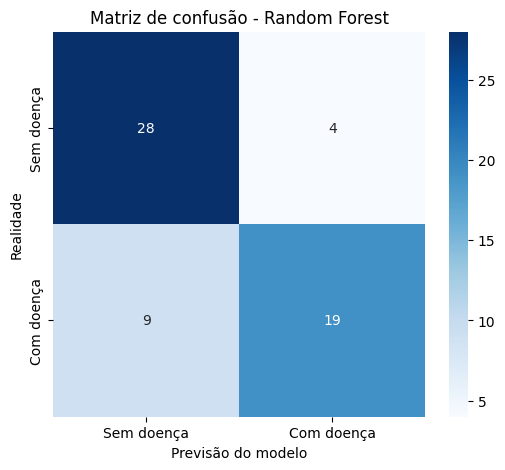

              precision    recall  f1-score   support

  Sem doença       0.76      0.88      0.81        32
  Com doença       0.83      0.68      0.75        28

    accuracy                           0.78        60
   macro avg       0.79      0.78      0.78        60
weighted avg       0.79      0.78      0.78        60



In [41]:
#Então para isso vamos usar uma matriz de confusão, uma tabela que mostra quantos pacientes caíram em cada uma das 4 combinações possíveis
#A matriz retorna a precisão de cada tipo de resultado (mede o quanto dá pra confiar quando o modelo diz "tem doença").
#O recall é um pouco diferente da precisão, ele se baseia no total de pacientes, ou seja, enquanto a precisão mede a porcentagem de quanto o algorítimo pelo que ele mesmo disse.
#o recall mede o quanto ele acertou do total que eram certos, ent faz sentido o recall ser menor que a precisão. E o F1-score a junção dos 2.


matriz_confusao = confusion_matrix(y_teste, previsoes_rf)

plt.figure(figsize=(6, 5))
sns.heatmap(matriz_confusao, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Sem doença', 'Com doença'],
            yticklabels=['Sem doença', 'Com doença'])
plt.xlabel('Previsão do modelo')
plt.ylabel('Realidade')
plt.title('Matriz de confusão - Random Forest')
plt.show()

print(classification_report(y_teste, previsoes_rf, target_names=['Sem doença', 'Com doença']))

In [42]:
#Com esses resultados foi possível perceber que, o modelo quando diz que tem doença ele acerta 83% das vezes, já de todo mundo que realmente tem a doença ele acerta somente 68% das vezes.

In [43]:
#Finalizando essa parte é possível perceber algumas coisas, dentre os modelos testados, o RandomForestClassifier apresentou o melhor desempenho
#geral, com acurácia de 78,3%, mas apesar desse bom resultado a matriz de confusão idenfiticou 9 falsos negativos, ou seja, pessoas que tinham a doença
#mas o modelo disse que elas não tinham, resultando em um recall de apenas 68%, particularmente preocupante, pois pode levar a um paciente doente não receber
#o acompanhamento médico necessário.

In [44]:
#Só pra curiosidade aqui está um exemplo de como seria um teste do modelo de forma mais comparativa.
comparacao = pd.DataFrame({
    'Real': y_teste,
    'Previsto': previsoes_rf
})

comparacao['Real'] = comparacao['Real'].map({0: 'Sem doença', 1: 'Com doença'})
comparacao['Previsto'] = comparacao['Previsto'].map({0: 'Sem doença', 1: 'Com doença'})
comparacao['Acertou?'] = comparacao['Real'] == comparacao['Previsto']

comparacao.head(60)

,Real,Previsto,Acertou?
295,Sem doença,Sem doença,True
242,Sem doença,Sem doença,True
90,Sem doença,Sem doença,True
102,Sem doença,Com doença,False
67,Sem doença,Sem doença,True
255,Sem doença,Sem doença,True
23,Com doença,Com doença,True
238,Sem doença,Sem doença,True
66,Com doença,Sem doença,False
200,Sem doença,Sem doença,True
